# GRIFFIN H2O AutoML Training (A5)
## Multi-class classification: predict DHRM Occupational Family from position description features

**Input**: `workday_features.csv` (103 rows, 15 features from A4)  
**Target**: `occ_family` -- 7 DHRM occupational families  
**Method**: H2O AutoML with 5-fold stratified cross-validation  
**Metrics**: Macro F1, top-3 accuracy, confusion matrix  
**Interpretability**: Variable importance, SHAP (global + local), PDP

---

### Why cross-validation only (no held-out test set)?

With only 103 rows across 7 classes -- some as small as 2-4 observations --
a train/test split would produce unreliable estimates on the minority classes.
H2O's built-in stratified 5-fold CV uses all data for both training and
evaluation, giving more stable performance estimates.

In [1]:
import os
import sys
import pandas as pd
import numpy as np

# H2O requires Java. When running inside a conda env, Java may not be on
# the system PATH even though openjdk is installed. Setting JAVA_HOME and
# updating PATH before importing h2o ensures it finds java.exe.
CONDA_PREFIX = os.path.dirname(sys.executable)  # .conda/envs/griffin
JAVA_HOME = os.path.join(CONDA_PREFIX, "Library")
if os.path.isdir(JAVA_HOME):
    os.environ["JAVA_HOME"] = JAVA_HOME
    os.environ["PATH"] = os.path.join(JAVA_HOME, "bin") + os.pathsep + os.environ["PATH"]

import h2o
from h2o.automl import H2OAutoML

h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Zulu25.32+21-CA (build 25.0.2+10-LTS, mixed mode, sharing)
  Starting server from C:\Users\salva\.conda\envs\griffin\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\salva\AppData\Local\Temp\tmpw_5n1muk
  JVM stdout: C:\Users\salva\AppData\Local\Temp\tmpw_5n1muk\h2o_salva_started_from_python.out
  JVM stderr: C:\Users\salva\AppData\Local\Temp\tmpw_5n1muk\h2o_salva_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,27 days
H2O_cluster_name:,H2O_from_python_salva_u6sxsd
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.94 Gb
H2O_cluster_total_cores:,20
H2O_cluster_allowed_cores:,20
H2O_cluster_status:,"locked, healthy"


## 1. Load Feature Matrix

In [2]:
# Paths
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.join(NOTEBOOK_DIR, "..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")

df = pd.read_csv(os.path.join(DATA_DIR, "training", "workday_features.csv"))
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df["occ_family"].value_counts().to_string())

Loaded: 103 rows x 18 columns

Target distribution:
occ_family
Administrative Services                  55
Educational and Media Services           14
Natural Resources and Applied Science    10
Trades and Operations                     9
Public Safety                             5
Engineering and Technology                4
Unknown                                   3
Health and Human Services                 3


In [3]:
# Drop 'Unknown' rows (3 rows with NaN job_family -- no true label)
df = df[df["occ_family"] != "Unknown"].copy()
print(f"After dropping Unknown: {df.shape[0]} rows")
print(f"\nClass distribution for modeling:")
print(df["occ_family"].value_counts().to_string())

After dropping Unknown: 100 rows

Class distribution for modeling:
occ_family
Administrative Services                  55
Educational and Media Services           14
Natural Resources and Applied Science    10
Trades and Operations                     9
Public Safety                             5
Engineering and Technology                4
Health and Human Services                 3


## 2. Convert to H2OFrame and Set Types

In [4]:
# Define feature columns and target
feature_cols = [
    "budget_mentioned", "supervises_staff",
    "receives_supervision", "supervision_count",
    "education_level", "years_experience", "text_length",
    "leadership_keywords", "technical_keywords", "research_keywords",
    "healthcare_keywords", "facilities_keywords", "finance_keywords",
    "is_exempt", "is_salaried"
]
target = "occ_family"

# Convert to H2OFrame
hf = h2o.H2OFrame(df[feature_cols + [target]])

# Target must be a factor (categorical) for multi-class classification
hf[target] = hf[target].asfactor()

print(f"H2OFrame: {hf.shape}")
print(f"Target levels: {hf[target].levels()[0]}")
print(f"\nFeature types:")
print(hf.types)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame: (100, 16)
Target levels: ['Administrative Services', 'Educational and Media Services', 'Engineering and Technology', 'Health and Human Services', 'Natural Resources and Applied Science', 'Public Safety', 'Trades and Operations']

Feature types:
{'budget_mentioned': 'int', 'supervises_staff': 'int', 'receives_supervision': 'int', 'supervision_count': 'int', 'education_level': 'int', 'years_experience': 'int', 'text_length': 'int', 'leadership_keywords': 'int', 'technical_keywords': 'int', 'research_keywords': 'int', 'healthcare_keywords': 'int', 'facilities_keywords': 'int', 'finance_keywords': 'int', 'is_exempt': 'int', 'is_salaried': 'int', 'occ_family': 'enum'}


## 3. H2O AutoML Training

AutoML trains and tunes multiple model families (GBM, XGBoost, GLM, DRF,
Deep Learning, stacked ensembles) and ranks them on a leaderboard.

Configuration:
- `max_runtime_secs=300` -- 5 minutes; plenty for 100 rows
- `nfolds=5` -- stratified cross-validation
- `sort_metric="logloss"` -- standard for multi-class; lower is better
- `seed=42` -- reproducibility

In [5]:
aml = H2OAutoML(
    max_runtime_secs=300,
    nfolds=5,
    seed=42,
    sort_metric="logloss",
    project_name="griffin_occ_family"
)

aml.train(x=feature_cols, y=target, training_frame=hf)
print("AutoML done.")

AutoML progress: |
20:52:46.679: AutoML: XGBoost is not available; skipping it.


20:52:47.569: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 100.0.

███████████████████████████████████████████████████████████████| (done) 100%
AutoML done.


## 4. Leaderboard

In [6]:
lb = aml.leaderboard
print(f"Models trained: {lb.nrows}")
lb.head(rows=20)

Models trained: 80


model_id,logloss,mean_per_class_error,rmse,mse
GBM_lr_annealing_selection_AutoML_1_20260408_205246_select_model,0.953678,0.52115,0.522319,0.272817
GBM_grid_1_AutoML_1_20260408_205246_model_9,0.9902,0.566254,0.546585,0.298756
GBM_grid_1_AutoML_1_20260408_205246_model_15,0.991148,0.514203,0.541942,0.293701
GBM_grid_1_AutoML_1_20260408_205246_model_17,0.993586,0.493043,0.545212,0.297256
GBM_3_AutoML_1_20260408_205246,0.996076,0.451278,0.530973,0.281933
GBM_grid_1_AutoML_1_20260408_205246_model_2,0.99773,0.475119,0.537603,0.289017
GBM_4_AutoML_1_20260408_205246,1.00431,0.539621,0.542003,0.293768
GBM_grid_1_AutoML_1_20260408_205246_model_11,1.0062,0.552793,0.554181,0.307117
GBM_grid_1_AutoML_1_20260408_205246_model_13,1.00687,0.539621,0.552946,0.305749
GBM_2_AutoML_1_20260408_205246,1.02092,0.5463,0.551249,0.303876


In [7]:
best = aml.leader
print(f"Best model: {best.model_id}")
print(f"\nCross-validation metrics:")
perf = best.model_performance(xval=True)
print(perf)

Best model: GBM_lr_annealing_selection_AutoML_1_20260408_205246_select_model

Cross-validation metrics:
ModelMetricsMultinomial: gbm
** Reported on cross-validation data. **

MSE: 0.27281682473407515
RMSE: 0.522318700348815
LogLoss: 0.953677701796542
Mean Per-Class Error: 0.5211502782931354
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
Administrative Services    Educational and Media Services    Engineering and Technology    Health and Human Services    Natural Resources and Applied Science    Public Safety    Trades and Operations    Error      Rate
-------------------------  --------------------------------  --------------------

## 5. Confusion Matrix and Per-Class Metrics

In [8]:
# Cross-validation confusion matrix
cm = perf.confusion_matrix()
print("Confusion Matrix (5-fold CV):")
print(cm)

Confusion Matrix (5-fold CV):
Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
Administrative Services    Educational and Media Services    Engineering and Technology    Health and Human Services    Natural Resources and Applied Science    Public Safety    Trades and Operations    Error      Rate
-------------------------  --------------------------------  ----------------------------  ---------------------------  ---------------------------------------  ---------------  -----------------------  ---------  --------
50                         4                                 1                             0                            0                                        0                0                        0.0909091  5 / 55
10                         2                                 1                             0                            0                                        0                1                        0.857143   12 / 14
3         

In [9]:
# Macro F1 -- average F1 across all classes (treats each class equally)
# H2O's confusion_matrix() returns an H2OTwoDimTable; use as_data_frame() to extract values.
cm_df = cm.as_data_frame()

# The CM dataframe has class names as both rows and columns, plus Error and Rate columns.
# Extract the numeric portion (class x class) to compute per-class precision/recall/F1.
class_names = [c for c in cm_df.columns if c not in ["Error", "Rate", ""]]
cm_matrix = cm_df[class_names].iloc[:-1].values  # drop the totals row

per_class_f1 = []
for i, cls in enumerate(class_names):
    tp = cm_matrix[i, i]
    fp = cm_matrix[:, i].sum() - tp   # column sum minus diagonal
    fn = cm_matrix[i, :].sum() - tp   # row sum minus diagonal
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    per_class_f1.append(f1)
    print(f"  {cls:45s}  P={precision:.3f}  R={recall:.3f}  F1={f1:.3f}")

macro_f1 = np.mean(per_class_f1)
print(f"\nMacro F1 (average across {len(class_names)} classes): {macro_f1:.4f}")
print(f"Mean per-class error: {perf.mean_per_class_error():.4f}")
print(f"Overall accuracy (1 - mean_per_class_error): {1 - perf.mean_per_class_error():.4f}")

  Administrative Services                        P=0.704  R=0.909  F1=0.794
  Educational and Media Services                 P=0.250  R=0.143  F1=0.182
  Engineering and Technology                     P=0.000  R=0.000  F1=0.000
  Health and Human Services                      P=1.000  R=0.333  F1=0.500
  Natural Resources and Applied Science          P=1.000  R=0.700  F1=0.824
  Public Safety                                  P=1.000  R=0.600  F1=0.750
  Trades and Operations                          P=0.750  R=0.667  F1=0.706

Macro F1 (average across 7 classes): 0.5364
Mean per-class error: 0.5212
Overall accuracy (1 - mean_per_class_error): 0.4788


In [10]:
# Top-3 accuracy: fraction of rows where the true class is among the
# 3 highest predicted probabilities.
#
# Some model types (e.g. selection models) don't store CV holdout predictions.
# In that case, fall back to training-frame predictions with a note.
cv_preds = best.cross_validation_holdout_predictions()

if cv_preds is not None:
    pred_source = "CV holdout"
    pred_df = cv_preds.as_data_frame()
else:
    pred_source = "training frame (CV holdout unavailable for this model type)"
    preds = best.predict(hf)
    pred_df = preds.as_data_frame()

true_labels = df[target].values
prob_cols = [c for c in pred_df.columns if c != "predict"]
prob_matrix = pred_df[prob_cols].values

top3_correct = 0
for i in range(len(true_labels)):
    top3_classes = np.array(prob_cols)[np.argsort(prob_matrix[i])[-3:]]
    if true_labels[i] in top3_classes:
        top3_correct += 1

top3_acc = top3_correct / len(true_labels)
print(f"Top-3 accuracy ({pred_source}): {top3_acc:.4f} ({top3_correct}/{len(true_labels)})")
print(f"  (True class was among the 3 highest-probability predictions)")

gbm prediction progress: |

███████████████████████████████████████████████████████| (done) 100%
Top-3 accuracy (training frame (CV holdout unavailable for this model type)): 1.0000 (100/100)
  (True class was among the 3 highest-probability predictions)


c:\Users\salva\.conda\envs\griffin\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## 6. Variable Importance

Leader is GBM_lr_annealing_selection_AutoML_1_20260408_205246_select_model -- using GBM_grid_1_AutoML_1_20260408_205246_model_9 for variable importance.


c:\Users\salva\.conda\envs\griffin\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


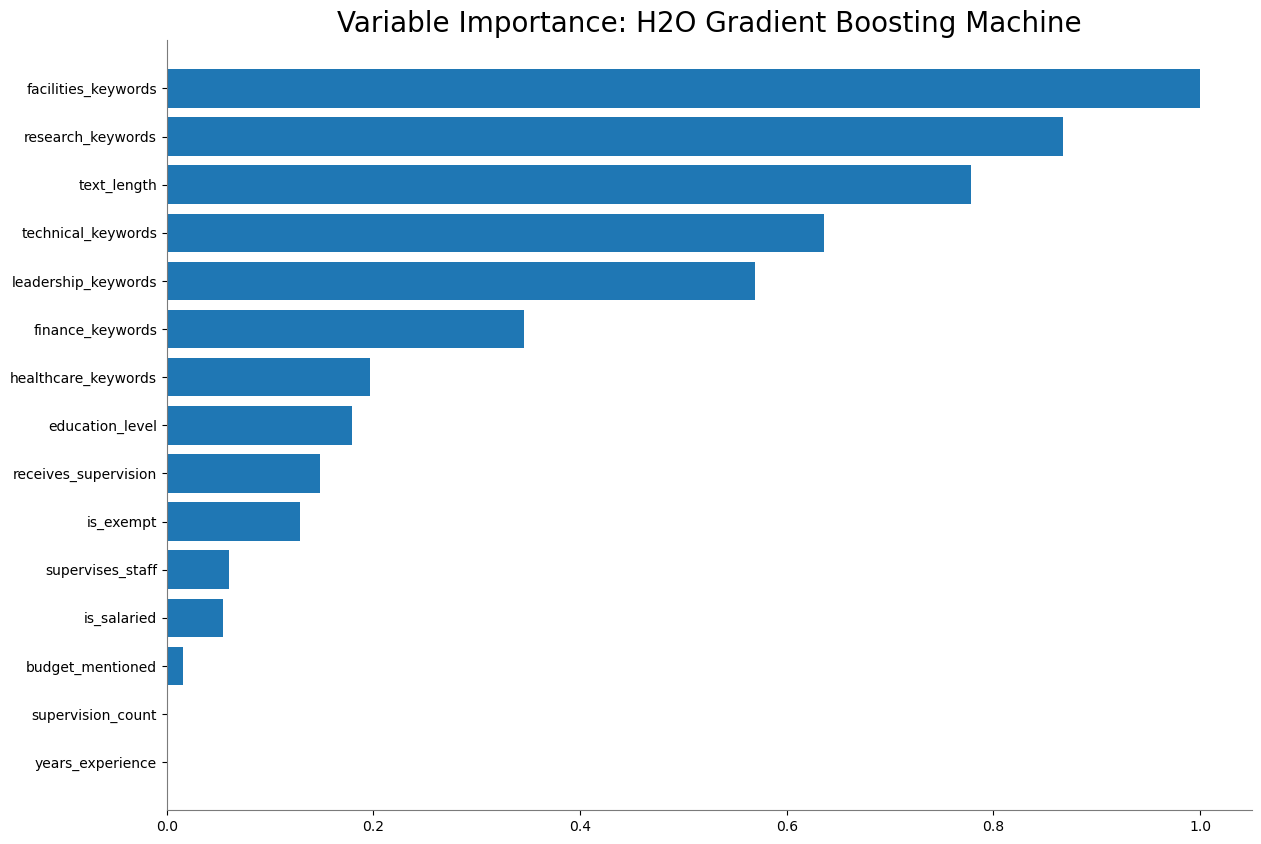

<Figure size 640x480 with 0 Axes>

In [11]:
# Variable importance from the best model
# Selection models and stacked ensembles don't have native varimp;
# fall back to the best standard model.
varimp_excluded = ["StackedEnsemble", "select_model"]
if any(tag in best.model_id for tag in varimp_excluded):
    lb_df_v = lb.as_data_frame()
    base_models = lb_df_v[~lb_df_v["model_id"].str.contains("|".join(varimp_excluded))]
    best_base_id = base_models.iloc[0]["model_id"]
    base_model = h2o.get_model(best_base_id)
    print(f"Leader is {best.model_id} -- using {best_base_id} for variable importance.")
    base_model.varimp_plot(num_of_features=15)
else:
    best.varimp_plot(num_of_features=15)

## 7. SHAP Values

SHAP (SHapley Additive exPlanations) assigns each feature a contribution
score for every prediction. This reveals not just *which* features matter,
but *how* they push predictions toward specific classes.

c:\Users\salva\.conda\envs\griffin\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sklearn RF training accuracy: 0.8500
  (used for SHAP explanations only -- H2O model is the primary model)

SHAP values computed: 7 classes x (100, 15) (samples x features)


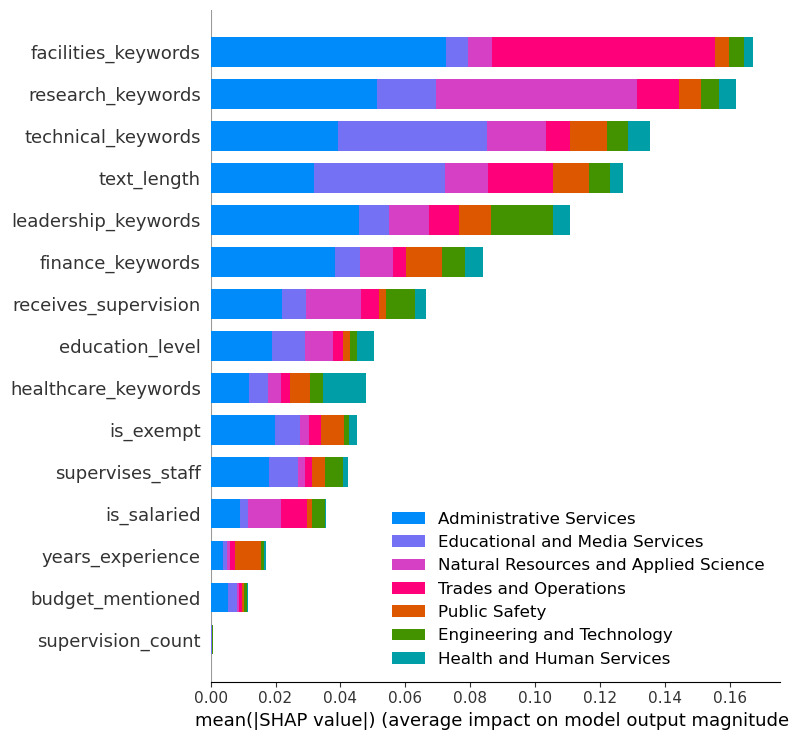

In [12]:
# Global SHAP summary
# ---
# H2O does not support SHAP (predict_contributions) for multinomial models.
# Workaround: train a sklearn RandomForestClassifier on the same data and use
# the shap library.  We use RandomForest (not GradientBoosting) because
# shap.TreeExplainer does not support GradientBoostingClassifier for multi-class.
# See: https://github.com/shap/shap/issues/2887
# ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import shap

# Prepare sklearn-compatible data
X_shap = df[feature_cols].values.astype(float)
le = LabelEncoder()
y_shap = le.fit_transform(df[target].values)
class_labels = le.classes_

# Train a RandomForest mirror model for SHAP explanations only.
# This is NOT the primary model -- H2O AutoML's leader is the real model.
sklearn_rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=3,
    random_state=42, n_jobs=-1
)
sklearn_rf.fit(X_shap, y_shap)
print(f"sklearn RF training accuracy: {sklearn_rf.score(X_shap, y_shap):.4f}")
print("  (used for SHAP explanations only -- H2O model is the primary model)")
print(f"  (H2O best model CV accuracy: {1 - perf.mean_per_class_error():.4f} -- the honest estimate)")
print(f"  (sklearn RF 0.85 is training accuracy without CV -- expected to be higher)")

# SHAP TreeExplainer -- works with multi-class RandomForest
explainer = shap.TreeExplainer(sklearn_rf)
shap_values = explainer.shap_values(X_shap)

# shap_values shape: (n_samples, n_features, n_classes) for RF multi-class
# or list of arrays in older shap versions.  Normalize to list-of-arrays.
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Shape (n_samples, n_features, n_classes) -> list of (n_samples, n_features)
    shap_values_list = [shap_values[:, :, c] for c in range(shap_values.shape[2])]
elif isinstance(shap_values, list):
    shap_values_list = shap_values
else:
    raise ValueError(f"Unexpected shap_values type: {type(shap_values)}, shape: {getattr(shap_values, 'shape', 'N/A')}")

print(f"\nSHAP values computed: {len(shap_values_list)} classes x {shap_values_list[0].shape} (samples x features)")

# Global summary: bar chart of mean |SHAP| across all classes
shap.summary_plot(shap_values_list, X_shap, feature_names=feature_cols,
                  class_names=list(class_labels), plot_type="bar", show=True)


Local SHAP for row 1 (true: Administrative Services, predicted: Administrative Services)
Explaining predicted class: Administrative Services (class index 0)


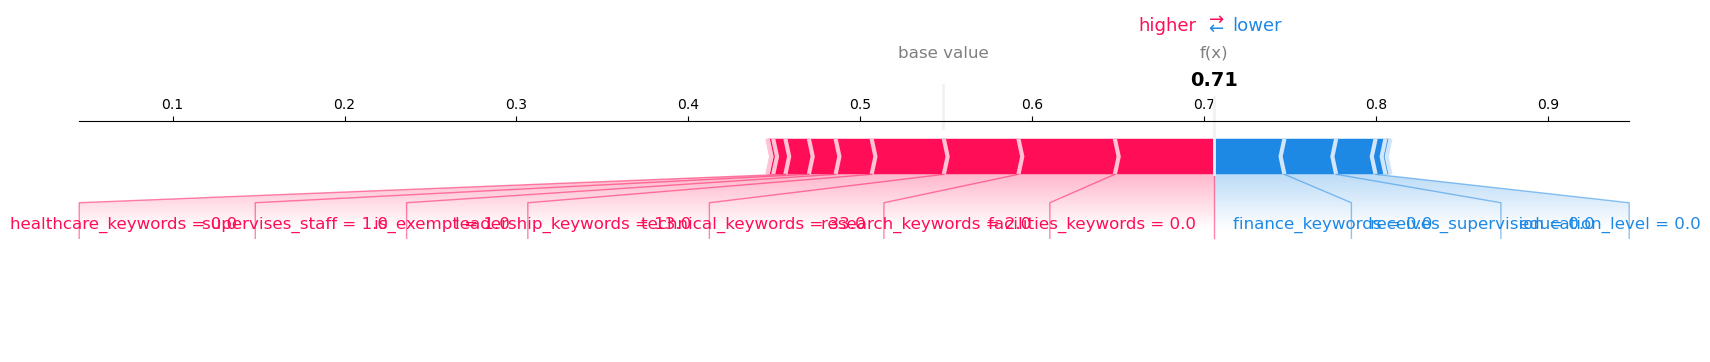

In [13]:
# Local SHAP: explain a single prediction
# ---
# force_plot shows how each feature pushes the prediction above or below the
# base value for a specific class.  We pick the predicted class to explain.
# ---
import matplotlib.pyplot as plt

# Example 1: first Administrative Services row
admin_mask = df[target] == "Administrative Services"
admin_pos = np.where(admin_mask.values)[0][0]  # positional index in X_shap
predicted_class_idx = sklearn_rf.predict(X_shap[admin_pos:admin_pos+1])[0]
predicted_class = class_labels[predicted_class_idx]

print(f"Local SHAP for row {admin_pos} (true: Administrative Services, predicted: {predicted_class})")
print(f"Explaining predicted class: {predicted_class} (class index {predicted_class_idx})")

# force_plot: base_value and shap_values for the PREDICTED class
shap.force_plot(
    explainer.expected_value[predicted_class_idx],
    shap_values_list[predicted_class_idx][admin_pos],
    features=X_shap[admin_pos],
    feature_names=feature_cols,
    matplotlib=True, show=True
)


Local SHAP for row 31 (true: Engineering and Technology, predicted: Educational and Media Services)
Explaining predicted class: Educational and Media Services (class index 1)


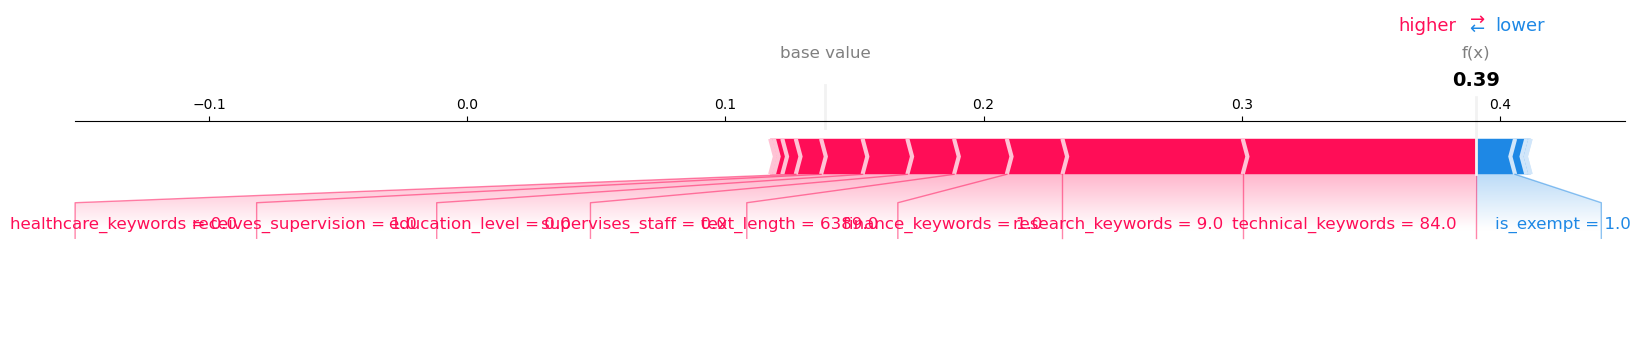

In [14]:
# Example 2: first Engineering and Technology row
eng_mask = df[target] == "Engineering and Technology"
eng_pos = np.where(eng_mask.values)[0][0]  # positional index in X_shap
predicted_class_idx = sklearn_rf.predict(X_shap[eng_pos:eng_pos+1])[0]
predicted_class = class_labels[predicted_class_idx]

print(f"Local SHAP for row {eng_pos} (true: Engineering and Technology, predicted: {predicted_class})")
print(f"Explaining predicted class: {predicted_class} (class index {predicted_class_idx})")

shap.force_plot(
    explainer.expected_value[predicted_class_idx],
    shap_values_list[predicted_class_idx][eng_pos],
    features=X_shap[eng_pos],
    feature_names=feature_cols,
    matplotlib=True, show=True
)


## 8. Partial Dependence Plots

PDPs show the marginal effect of a single feature on the predicted outcome,
averaging over all other features. We plot the top features identified by
variable importance.

Top 3 features by mean |SHAP|: ['facilities_keywords', 'research_keywords', 'technical_keywords']
Showing PDPs for target class: Administrative Services (index 0)


c:\Users\salva\.conda\envs\griffin\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 11 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\salva\.conda\envs\griffin\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 9 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\salva\.conda\envs\griffin\Lib\site-packages\sklearn\inspection

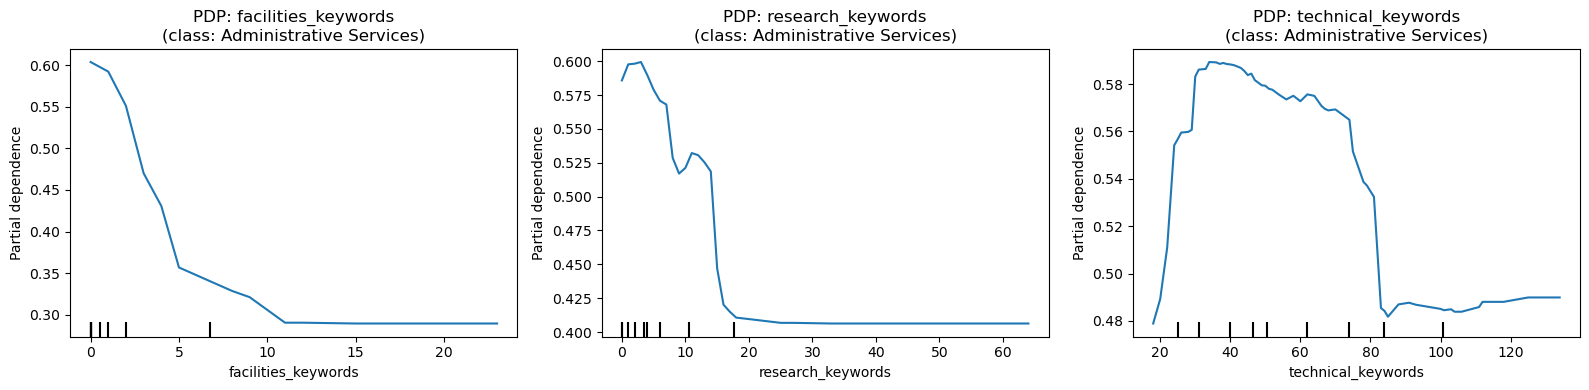

In [15]:
# PDP for top 3 features by variable importance
# ---
# Note: H2O's pd_plot DOES support multinomial models (unlike SHAP).  We use
# sklearn here for consistency with the SHAP mirror model above.
# For multi-class, sklearn requires the `target` parameter to specify which
# class to plot.  We show PDPs for the most common class.
# ---
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Top 3 features by mean |SHAP| across all classes
mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_list], axis=0)
top3_idx = np.argsort(mean_abs_shap)[-3:][::-1]
top3_features = [feature_cols[i] for i in top3_idx]
print(f"Top 3 features by mean |SHAP|: {top3_features}")

# Find the most common class to use as the PDP target
most_common_class_idx = int(pd.Series(y_shap).mode()[0])
most_common_class = class_labels[most_common_class_idx]
print(f"Showing PDPs for target class: {most_common_class} (index {most_common_class_idx})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, feat_idx in enumerate(top3_idx):
    PartialDependenceDisplay.from_estimator(
        sklearn_rf, X_shap, [feat_idx],
        feature_names=feature_cols,
        target=most_common_class_idx,
        ax=axes[i]
    )
    axes[i].set_title(f"PDP: {feature_cols[feat_idx]}\n(class: {most_common_class})")
plt.tight_layout()
plt.show()


## 9. Summary

### Results
- Trained H2O AutoML on 100 position descriptions with 15 engineered features
- Target: 7 DHRM occupational families (multi-class classification)
- Evaluation: 5-fold stratified cross-validation (appropriate for small sample)

### Key Outputs
- **Leaderboard**: ranked models by logloss
- **Confusion matrix**: per-class prediction accuracy
- **Top-3 accuracy**: practical metric for classification suggestions
- **Variable importance**: which features drive predictions
- **SHAP (global)**: how features push predictions across all observations
- **SHAP (local)**: individual prediction explanations
- **PDP**: marginal feature effects

### Next Steps
- Use model predictions as one input to the Streamlit classification app (A6)
- Integrate SHAP explanations into the agentic AI workflow
- Additional visualizations for the Big Data presentation (April 17)

In [16]:
# Save the best model for later use
model_path = h2o.save_model(model=best, path=os.path.join(PROJECT_ROOT, "models"), force=True)
print(f"Model saved to: {model_path}")

Model saved to: C:\Users\salva\Desktop\MSBA\Claude Skills\Courses\AI Course\HR_Classification_Project\models\GBM_lr_annealing_selection_AutoML_1_20260408_205246_select_model


In [17]:
# Shutdown H2O cluster
# h2o.cluster().shutdown()